> Add tools 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/get-started/2-add-tools/>

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [3]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [4]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [5]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-09-22 17:58:18'

In [6]:
query = "2025년 KT 소액결제 사건의 원인은?"

In [7]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
2025년 KT 소액결제 사건의 원인은?
m
1. snippet: 2 weeks ago - 왜 KT만 털렸나 무단 소액결제 사건 의문점 3가지 KT는 11일 불법 초소형 기지국을 통해 일부 고객의 국제이동가입자식별정보IMSI 정보가 유출된 것을 확인하고 이를 개인정보보호위원회에 신고했다고 밝혔다., title: Chosun Daily 왜 KT만 털렸나… ‘무단 소액결제’ 사건 의문점 3가지, link: https://www.chosun.com/economy/tech_it/2025/09/11/P6IGLCLDPFFARKYDTBAPSIHFYA/
2. snippet: 2 weeks ago - KT 소액결제 피해 사건의 원인이 ‘ 불법 기지국 ’이라는 정황이 나왔다. 해커들이 불법 기지국 을 설치해 이용자들의 통신 정보를 탈취했을 가능성이 제기된 것으로, 국내에선 발생한 적 없는 사건이다.KT는 지난 8일 ..., title: MediaToday ‘KT 소액결제 사건’ 원인은 불법 기지국? “서버 전수조사해야”, link: https://www.mediatoday.co.kr/news/articleView.html?idxno=328721
3. snippet: 5 days ago - (수원=연합뉴스) 강영훈 기자 = KT 무단 소액결제 사건의 용의자인 중국 국적의 남성들이 경찰에 붙잡혔다., title: Yonhap News Agency 'KT 소액결제' 사건 40대 중국교포 용의자 2명 검거(종합) | 연합뉴스, link: https://www.yna.co.kr/view/AKR20250917145452061
4. snippet: 1 week ago - 구형 장비·단말기 ‘폴백’ 가능성 제기, 인증 가로채 결제 도용 가능, “펨토셀 보안 점검· 소액결제 인증 체계 보완 시급”, title: Byline KT 소액결제 피해, 전문가가 분석한 펨토셀 해킹 시나리오 – 바이라인네트워크, link: https://byline.

"snippet: 2 weeks ago - 왜 KT만 털렸나 무단 소액결제 사건 의문점 3가지 KT는 11일 불법 초소형 기지국을 통해 일부 고객의 국제이동가입자식별정보IMSI 정보가 유출된 것을 확인하고 이를 개인정보보호위원회에 신고했다고 밝혔다., title: Chosun Daily 왜 KT만 털렸나… ‘무단 소액결제’ 사건 의문점 3가지, link: https://www.chosun.com/economy/tech_it/2025/09/11/P6IGLCLDPFFARKYDTBAPSIHFYA/;\nsnippet: 2 weeks ago - KT 소액결제 피해 사건의 원인이 ‘ 불법 기지국 ’이라는 정황이 나왔다. 해커들이 불법 기지국 을 설치해 이용자들의 통신 정보를 탈취했을 가능성이 제기된 것으로, 국내에선 발생한 적 없는 사건이다.KT는 지난 8일 ..., title: MediaToday ‘KT 소액결제 사건’ 원인은 불법 기지국? “서버 전수조사해야”, link: https://www.mediatoday.co.kr/news/articleView.html?idxno=328721;\nsnippet: 5 days ago - (수원=연합뉴스) 강영훈 기자 = KT 무단 소액결제 사건의 용의자인 중국 국적의 남성들이 경찰에 붙잡혔다., title: Yonhap News Agency 'KT 소액결제' 사건 40대 중국교포 용의자 2명 검거(종합) | 연합뉴스, link: https://www.yna.co.kr/view/AKR20250917145452061;\nsnippet: 1 week ago - 구형 장비·단말기 ‘폴백’ 가능성 제기, 인증 가로채 결제 도용 가능, “펨토셀 보안 점검· 소액결제 인증 체계 보완 시급”, title: Byline KT 소액결제 피해, 전문가가 분석한 펨토셀 해킹 시나리오 – 바이라인네트워크, link: https://byline.network/2025/09/16-546/"

In [8]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x00000229C1A29440>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x00000229C1A28FE0>


In [9]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [10]:
tools

[StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x00000229C1A29440>),
 StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x00000229C1A28FE0>)]

In [11]:
from pprint import pprint

# * 딕셔너리 컴프리헨션(Dictionary Comprehension)
# - 키(Key): tool.name은 현재 순회 중인 StructuredTool 객체의 name 속성 값을 추출하여 딕셔너리의 키로 사용한다.
# - 값(Value): tool은 현재 순회 중인 StructuredTool 객체 자체를 딕셔너리의 값으로 사용한다.
pprint({tool.name: tool for tool in tools})

{'get_current_time': StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x00000229C1A29440>),
 'get_web_search': StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x00000229C1A28FE0>)}


In [12]:
# * 왈러스(walrus) 연산자
# - 바다코끼리 닮아서 붙여진 이름
# - Python 3.8부터 도입된 문법
# - 일반적인 할당 연산자 (=)가 문(statement)인 반면, 왈러스 연산자는 식(expression)
# - 변수에 값을 할당하면서 동시에 그 값에 대한 참/거짓을 판별
dic = {"messages": ["a", "b"]}
if var := dic.get("messages"):
    print(var)

['a', 'b']


In [13]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    """

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools} # 딕셔너리 컴프리헨션(Dictionary Comprehension)

    def __call__(self, inputs: dict):
        # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
        if messages := inputs.get("messages", []): # 왈러스(walrus) 연산자 사용
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [14]:
# * Case1
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [ ]:
# * Case2
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [16]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [17]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [18]:
graph = graph_builder.compile()

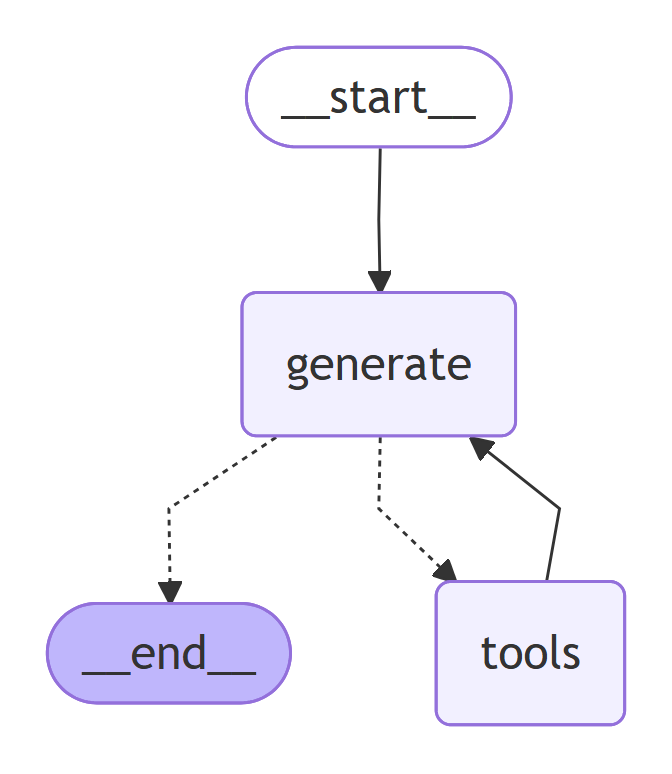

In [19]:
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

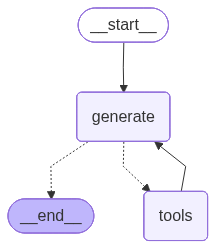

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [21]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

지금 부산은 2025년 9월 22일 17시 59분입니다.


In [22]:
gathered

AIMessageChunk(content='지금 부산은 2025년 9월 22일 17시 59분입니다.\n', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.0-flashgemini-2.0-flash', 'safety_ratings': []}, id='run--be401b8c-905c-4ebb-aeea-408298816314', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': 'd64cbc46-dec6-4653-bfc5-8f4776eb06f1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 41, 'total_tokens': 254, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': 'd64cbc46-dec6-4653-bfc5-8f4776eb06f1', 'index': None, 'type': 'tool_call_chunk'}])

In [23]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg


-------- WEB SEARCH --------
2025년 KT 소액결제
3개월
1. snippet: 4 days ago · KT 는 18일 브리핑을 통해 " 소액결제 피해 관련 최초 침해 및 개인정보 유출 발표 이후 침해 정황을 확인하고 보호 조치를 이행했다"며 "피해 고객 수는 당초 278명에서 362명으로, 누적 피해 금액은 2억4천만원으로 집계됐다"고 발표했다., title: KT "소액결제 피해 추가 확인…피해자 362명으로 늘어"(종합) | 연합뉴..., link: https://www.yna.co.kr/view/AKR20250918130100017
2. snippet: Sep 9, 2025 · 1. 사건 개요 발생 지역: 경기 광명시 (소하동·하안동)와 서울 금천구 특정 아파트 단지 발생 시기: 2025년 8월 27일 첫 신고 이후 ~ 9월 6일 피해 규모: 총 74건, 4,580만원 피해 광명경찰서 61건 (3,800만원), 금천경찰서 13건 (780만원) 피해 시간대: 모두 새벽 시간대 발생 피해자 특징: 모두 KT 및 KT 망 알뜰폰 ..., title: KT 소액결제 해킹 사건 정리 (2025년 9월 기준) : 네이버 블로그, link: https://blog.naver.com/dempsirol4/224000370974
3. snippet: Sep 11, 2025 · 2025년 9월, KT 소액결제 피해가 공식적으로 인정되면서 많은 KT 이용자들이 충격에 빠졌습니다. 특히, 이번 사건은 단순한 기술 오류가 아닌 불법 초소형 기지국을 통해 개인 정보가 유출되고, 무단 소액 결제까지 이어진 중대한 보안 사고였습니다. 이번 글에서는 KT 소액결제 피해 공식인정의 배경부터 ..., title: KT 소액결제 피해 공식인정! 지금 당장 해야 할 예방방법 (2025년 9월..., link: https://lelepapa.tistory.com/entry/KT-소액결제-피해-공식인정-지금-당장-해야-할-예방방법-2025년-9월-기준
4. snippe

In [24]:
gathered

AIMessageChunk(content='알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.\n\n**1단계: 최근 이슈 검색 및 주제 선정**\n\n먼저, 최근 이슈를 검색하여 사람들이 가장 관심 있어 할 만한 주제를 선정하고, 선정 이유를 설명하겠습니다.\n\n최근 KT 소액결제 사건은 단순한 기술 오류를 넘어 불법 기지국을 이용한 개인 정보 유출 및 무단 결제라는 심각한 보안 사고로, 많은 이용자에게 금전적 피해와 함께 큰 불안감을 안겨주었습니다. 특히, KT의 미흡한 초기 대응과 소극적인 정보 공개는 사태를 더욱 악화시켰다는 비판이 제기되고 있습니다. 따라서, 저는 **KT 소액결제 사건의 원인 분석 및 책임 소재 규명, 그리고 재발 방지 대책 마련**에 초점을 맞춰 심층 분석 기사를 작성하고자 합니다. 이는 현재 가장 큰 이슈이며, 유사한 사고 방지를 위해 꼭 필요한 분석이라고 생각합니다.\n\n**목차**\n\n1.  **머리말:** KT 소액결제 사건 발생 및 피해 상황 요약, 문제 제기\n2.  **사건의 전말:**\n    *   사건 발생 경위 및 피해 규모 상세 분석 (최초 발생 시점, 피해 지역, 피해 금액 등)\n    *   피해자들의 증언 및 피해 사례 심층 취재\n    *   KT의 초기 대응 과정 및 문제점 지적 (늑장 대응, 정보 은폐 의혹 등)\n3.  **사건의 원인 분석:**\n    *   기술적 취약점 분석 (불법 기지국 공격, 보안 시스템 허점 등)\n    *   KT의 보안 시스템 및 관리 체계 문제점 심층 분석\n    *   관련 법규 및 제도 미비점 지적\n4.  **책임 소재 규명:**\n    *   KT의 법적 책임 및 도의적 책임 논의\n    *   관련 기관 (정부, 통신사)의 감독 소홀 책임 추궁\n5.  **재발 방지 대책:**\n    *   KT의 보안 시스템 강화 방안 제시\n    *   유사 사고 방지를 위한 법규 및 

In [25]:
print(gathered.content)

알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.

**1단계: 최근 이슈 검색 및 주제 선정**

먼저, 최근 이슈를 검색하여 사람들이 가장 관심 있어 할 만한 주제를 선정하고, 선정 이유를 설명하겠습니다.

최근 KT 소액결제 사건은 단순한 기술 오류를 넘어 불법 기지국을 이용한 개인 정보 유출 및 무단 결제라는 심각한 보안 사고로, 많은 이용자에게 금전적 피해와 함께 큰 불안감을 안겨주었습니다. 특히, KT의 미흡한 초기 대응과 소극적인 정보 공개는 사태를 더욱 악화시켰다는 비판이 제기되고 있습니다. 따라서, 저는 **KT 소액결제 사건의 원인 분석 및 책임 소재 규명, 그리고 재발 방지 대책 마련**에 초점을 맞춰 심층 분석 기사를 작성하고자 합니다. 이는 현재 가장 큰 이슈이며, 유사한 사고 방지를 위해 꼭 필요한 분석이라고 생각합니다.

**목차**

1.  **머리말:** KT 소액결제 사건 발생 및 피해 상황 요약, 문제 제기
2.  **사건의 전말:**
    *   사건 발생 경위 및 피해 규모 상세 분석 (최초 발생 시점, 피해 지역, 피해 금액 등)
    *   피해자들의 증언 및 피해 사례 심층 취재
    *   KT의 초기 대응 과정 및 문제점 지적 (늑장 대응, 정보 은폐 의혹 등)
3.  **사건의 원인 분석:**
    *   기술적 취약점 분석 (불법 기지국 공격, 보안 시스템 허점 등)
    *   KT의 보안 시스템 및 관리 체계 문제점 심층 분석
    *   관련 법규 및 제도 미비점 지적
4.  **책임 소재 규명:**
    *   KT의 법적 책임 및 도의적 책임 논의
    *   관련 기관 (정부, 통신사)의 감독 소홀 책임 추궁
5.  **재발 방지 대책:**
    *   KT의 보안 시스템 강화 방안 제시
    *   유사 사고 방지를 위한 법규 및 제도 개선 방안 제안
    *   소비자 보호를 위한 실질적인 대책 마련 촉구
6. 